## **SCMS Health-Tech Logistics — Supply Chain Analysis**

**Technical Challenge:** Data ingestion from Airtable, EDA & DQA, Transformation, Dashboard-ready export  
**Dataset:** USAID Supply Chain Shipment Pricing Dataset (10,324 records)

### **Airtable**

In [ ]:
pip install pyairtable python-dotenv duckdb pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 4.0 MB/s eta 0:00:00


In [ ]:
# ── Airtable credentials
AIRTABLE_TOKEN='REDACTED'
AIRTABLE_BASE_ID='REDACTED'
AIRTABLE_TABLE_ID='REDACTED'

# Write to .env so other cells can load via dotenv
with open('.env', 'w') as f:
    f.write(f"AIRTABLE_TOKEN='{AIRTABLE_TOKEN}'\n")
    f.write(f"AIRTABLE_BASE_ID='{AIRTABLE_BASE_ID}'\n")
    f.write(f"AIRTABLE_TABLE_ID='{AIRTABLE_TABLE_ID}'\n")
print('Credentials written to .env file.')

TOKEN   = AIRTABLE_TOKEN
BASE_ID = AIRTABLE_BASE_ID
TABLE_ID = AIRTABLE_TABLE_ID

print(f'AIRTABLE_TOKEN:    {TOKEN[:5]}...{TOKEN[-5:]} (masked)')
print(f'AIRTABLE_BASE_ID:  {BASE_ID}')
print(f'AIRTABLE_TABLE_ID: {TABLE_ID}')

if TOKEN and BASE_ID and TABLE_ID:
    print('Airtable credentials loaded successfully!')
else:
    print('Failed to load all Airtable credentials. Please check your variables.')

#### **Extracting Airtable table data**

In [ ]:
import os, time, duckdb, pandas as pd
from pyairtable import Api
from dotenv import load_dotenv

# Initializing API
api   = Api(TOKEN)
table = api.table(BASE_ID, TABLE_ID)

all_records = []
page_num    = 0

for page in table.iterate(page_size=100):
    all_records.extend(page)
    page_num += 1
    print(f'  Fetched page {page_num} | Total records: {len(all_records)}')
    time.sleep(0.25)

# Change to DataFrame
rows = [r['fields'] for r in all_records]
df   = pd.DataFrame(rows)

# Integrity check
assert len(df) >= 500, f'Expected 500+ rows, got {len(df)}'
assert 'Country' in df.columns, 'Country column missing'
assert 'Shipment Mode' in df.columns, 'Shipment Mode column missing'
print(f'Integrity checks passed. Shape: {df.shape}')

#  Write to DuckDB
con = duckdb.connect('scms_raw.duckdb')
con.execute('DROP TABLE IF EXISTS raw_shipments')
con.execute('CREATE TABLE raw_shipments AS SELECT * FROM df')

# Verify write
count = con.execute('SELECT COUNT(*) FROM raw_shipments').fetchone()[0]
print(f'Written to DuckDB: {count} rows')
con.close()

  Fetched page 1 | Total records: 100
  Fetched page 2 | Total records: 200
  Fetched page 3 | Total records: 300
  Fetched page 4 | Total records: 400
  Fetched page 5 | Total records: 500
  Fetched page 6 | Total records: 600
  Fetched page 7 | Total records: 700
  Fetched page 8 | Total records: 800
  Fetched page 9 | Total records: 900
  Fetched page 10 | Total records: 1000
  Fetched page 11 | Total records: 1100
  Fetched page 12 | Total records: 1200
  Fetched page 13 | Total records: 1300
  Fetched page 14 | Total records: 1400
  Fetched page 15 | Total records: 1500
  Fetched page 16 | Total records: 1600
  Fetched page 17 | Total records: 1700
  Fetched page 18 | Total records: 1800
  Fetched page 19 | Total records: 1900
  Fetched page 20 | Total records: 2000
  Fetched page 21 | Total records: 2100
  Fetched page 22 | Total records: 2200
  Fetched page 23 | Total records: 2300
  Fetched page 24 | Total records: 2400
  Fetched page 25 | Total records: 2500
  Fetched page 26 

In [ ]:
df.shape

(10324, 33)

In [ ]:
df.columns.tolist()

['ID',
 'Project Code',
 'PQ #',
 'PO / SO #',
 'ASN/DN #',
 'Country',
 'Managed By',
 'Fulfill Via',
 'Vendor INCO Term',
 'Shipment Mode',
 'PQ First Sent to Client Date',
 'PO Sent to Vendor Date',
 'Scheduled Delivery Date',
 'Delivered to Client Date',
 'Delivery Recorded Date',
 'Product Group',
 'Sub Classification',
 'Vendor',
 'Item Description',
 'Molecule/Test Type',
 'Brand',
 'Dosage',
 'Dosage Form',
 'Unit of Measure (Per Pack)',
 'Line Item Quantity',
 'Line Item Value',
 'Pack Price',
 'Unit Price',
 'Manufacturing Site',
 'First Line Designation',
 'Weight (Kilograms)',
 'Freight Cost (USD)',
 'Line Item Insurance (USD)']

### **EDA**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  object 
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 10324 non-null  object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [ ]:
import duckdb
con = duckdb.connect('scms_raw.duckdb')
print(con.execute('SELECT COUNT(*) FROM raw_shipments').fetchone())
print(con.execute('DESCRIBE raw_shipments').df())


(10324,)
                     column_name column_type null   key default extra
0                             ID     VARCHAR  YES  None    None  None
1                   Project Code     VARCHAR  YES  None    None  None
2                           PQ #     VARCHAR  YES  None    None  None
3                      PO / SO #     VARCHAR  YES  None    None  None
4                       ASN/DN #     VARCHAR  YES  None    None  None
5                        Country     VARCHAR  YES  None    None  None
6                     Managed By     VARCHAR  YES  None    None  None
7                    Fulfill Via     VARCHAR  YES  None    None  None
8               Vendor INCO Term     VARCHAR  YES  None    None  None
9                  Shipment Mode     VARCHAR  YES  None    None  None
10  PQ First Sent to Client Date     VARCHAR  YES  None    None  None
11        PO Sent to Vendor Date     VARCHAR  YES  None    None  None
12       Scheduled Delivery Date     VARCHAR  YES  None    None  None
13      Del

#### **Data Quality Assessment**

Checking: **Completeness**, **Uniqueness**, **Validity**,
**Consistency**, **Integrity**, **Accuracy**, and **Timeliness**.

In [ ]:
import numpy as np

# ── Completeness ──────────────────────────────────────────────────────────────
def check_completeness(df):
    missing     = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)
    return pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}) \
             .sort_values('missing_pct', ascending=False)

# ── Uniqueness ────────────────────────────────────────────────────────────────
def check_uniqueness(df):
    return {
        'duplicate_rows': df.duplicated().sum(),
        'duplicate_ID':   df['ID'].duplicated().sum(),
        'duplicate_PO':   df['PO / SO #'].duplicated().sum()
    }

# ── Validity (date parseability) ──────────────────────────────────────────────
def check_validity(df):
    date_cols = [
        'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
        'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date'
    ]
    return {col: pd.to_datetime(df[col], errors='coerce').isna().sum() for col in date_cols}

# ── Consistency (Line Item Value = Pack Price × Quantity) ─────────────────────
def check_price_consistency(df):
    tmp = df.copy()
    tmp['calc_value'] = tmp['Pack Price'] * tmp['Line Item Quantity']
    tmp['price_diff'] = tmp['Line Item Value'] - tmp['calc_value']
    return len(tmp[tmp['price_diff'].abs() > 1])

# ── Integrity (date ordering) ─────────────────────────────────────────────────
def check_date_integrity(df):
    tmp = df.copy()
    for col in ['PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Delivered to Client Date']:
        tmp[col] = pd.to_datetime(tmp[col], errors='coerce', dayfirst=True)
    errors = tmp[
        (tmp['PO Sent to Vendor Date'] < tmp['PQ First Sent to Client Date']) |
        (tmp['Delivered to Client Date'] < tmp['PO Sent to Vendor Date'])
    ]
    return len(errors)

# ── Accuracy (Unit Price outliers via IQR) ────────────────────────────────────
def check_price_outliers(df):
    q1, q3 = df['Unit Price'].quantile(0.25), df['Unit Price'].quantile(0.75)
    return len(df[df['Unit Price'] > q3 + 1.5 * (q3 - q1)])

# ── Timeliness ────────────────────────────────────────────────────────────────
def check_timeliness(df):
    tmp = df.copy()
    tmp['Delivered to Client Date'] = pd.to_datetime(tmp['Delivered to Client Date'], errors='coerce', dayfirst=True)
    tmp['PO Sent to Vendor Date']   = pd.to_datetime(tmp['PO Sent to Vendor Date'],   errors='coerce', dayfirst=True)
    tmp['lead_time_days'] = (tmp['Delivered to Client Date'] - tmp['PO Sent to Vendor Date']).dt.days
    return {
        'avg_lead_time':   tmp['lead_time_days'].mean(),
        'negative_times':  len(tmp[tmp['lead_time_days'] < 0])
    }

# ── Run all checks ────────────────────────────────────────────────────────────
def run_dqa(df):
    return {
        'completeness': check_completeness(df),
        'uniqueness':   check_uniqueness(df),
        'validity':     check_validity(df),
        'consistency':  check_price_consistency(df),
        'integrity':    check_date_integrity(df),
        'accuracy':     check_price_outliers(df),
        'timeliness':   check_timeliness(df)
    }

dqa_report = run_dqa(df)
for category, result in dqa_report.items():
    print(f'\n--- {category.upper()} ---')
    print(result)

/tmp/ipykernel_6902/2162946987.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return {col: pd.to_datetime(df[col], errors='coerce').isna().sum() for col in date_cols}
/tmp/ipykernel_6902/2162946987.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return {col: pd.to_datetime(df[col], errors='coerce').isna().sum() for col in date_cols}
/tmp/ipykernel_6902/2162946987.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return {col: pd.to_datetime(df[col], errors='coerce').isna().sum() for col in date_cols}
/tmp/ipykernel_6902/2162946987.py:24: UserWarning: Could not 


--- COMPLETENESS ---
                              missing_count  missing_pct
Weight (Kilograms)                     1507        14.60
Line Item Insurance (USD)               287         2.78
ID                                        0         0.00
Project Code                              0         0.00
PQ #                                      0         0.00
Country                                   0         0.00
Managed By                                0         0.00
PO / SO #                                 0         0.00
ASN/DN #                                  0         0.00
Shipment Mode                             0         0.00
PQ First Sent to Client Date              0         0.00
PO Sent to Vendor Date                    0         0.00
Scheduled Delivery Date                   0         0.00
Delivered to Client Date                  0         0.00
Delivery Recorded Date                    0         0.00
Fulfill Via                               0         0.00
Vendor IN

/tmp/ipykernel_6902/2162946987.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tmp['PO Sent to Vendor Date']   = pd.to_datetime(tmp['PO Sent to Vendor Date'],   errors='coerce', dayfirst=True)


#### **Issues flagged during DQA.**

In [ ]:
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

# Issue 1: Weight & Freight stored as strings — limits cost/kg coverage
df['weight_num']  = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['freight_num'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')
usable = df.dropna(subset=['weight_num', 'freight_num'])
print(f'Issue 1 — Usable rows for cost/kg: {len(usable)} / {len(df)} ({len(usable)/len(df)*100:.1f}%)')

# Issue 2: Shipment Mode nulls
print(f'Issue 2 — Shipment Mode nulls: {df["Shipment Mode"].isna().sum()}')

# Issue 3: Negative delivery delay (delivered before scheduled)
df['sched'] = pd.to_datetime(df['Scheduled Delivery Date'],  errors='coerce', dayfirst=True)
df['deliv'] = pd.to_datetime(df['Delivered to Client Date'], errors='coerce', dayfirst=True)
df['delay'] = (df['deliv'] - df['sched']).dt.days
print(f'Issue 3 — Mean delay: {df["delay"].mean():.1f} days (negative = suspicious)')
print(f'          Min delay: {df["delay"].min()} days | Max: {df["delay"].max()} days')

# Issue 4: Dosage nulls
print(f'Issue 4 — Dosage nulls: {df["Dosage"].isna().sum()} ({df["Dosage"].isna().mean()*100:.1f}%)')

# Issue 5: Freight outliers
print(f'Issue 5 — Freight Cost: median={df["freight_num"].median():.0f}, max={df["freight_num"].max():.0f}')



Issue 1 — Usable rows for cost/kg: 6175 / 10324 (59.8%)
Issue 2 — Shipment Mode nulls: 0
Issue 3 — Mean delay: -6.0 days (negative = suspicious)
          Min delay: -372 days | Max: 192 days
Issue 4 — Dosage nulls: 0 (0.0%)
Issue 5 — Freight Cost: median=5870, max=289653



EDA plots saved.png


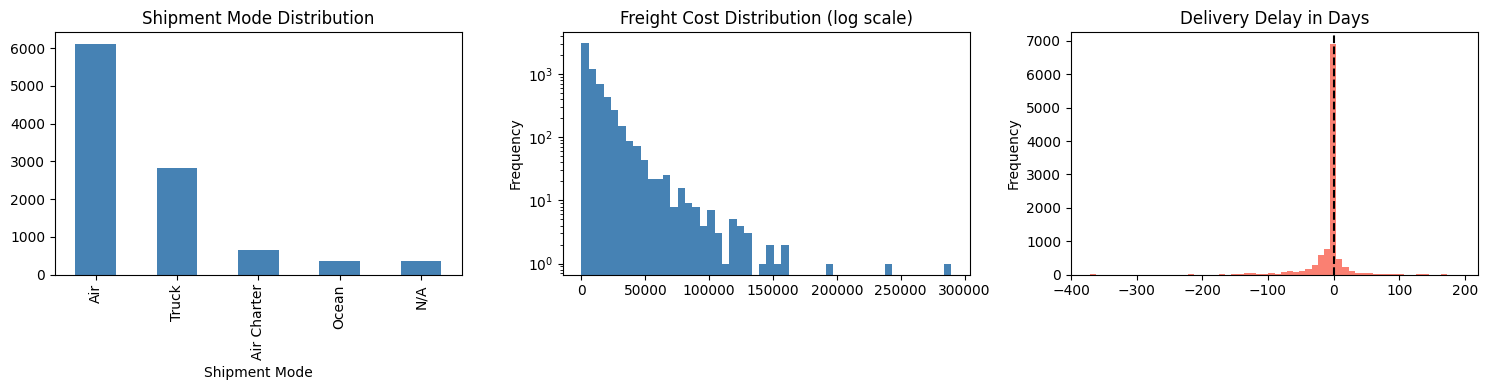

In [ ]:
# ── Visualisations ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Shipment Mode'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Shipment Mode Distribution')

df['freight_num'].dropna().plot(kind='hist', bins=50, ax=axes[1], color='steelblue', log=True)
axes[1].set_title('Freight Cost Distribution (log scale)')

df['delay'].plot(kind='hist', bins=60, ax=axes[2], color='salmon')
axes[2].set_title('Delivery Delay in Days')
axes[2].axvline(0, color='black', linestyle='--', label='On-time boundary')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
print('\nEDA plots saved.png')
plt.show()

#### Data Quality Issues Identified During EDA

| # | Dimension | Finding |
|---|-----------|----------|
| 1 | **Completeness** | `Weight (Kilograms)` — 14.60% missing (1,507 rows); `Line Item Insurance (USD)` — 2.78% missing (287 rows) |
| 2 | **Uniqueness** | 4,091 duplicate `PO / SO #` values — a single PO maps to multiple line items (expected but must be handled in aggregations) |
| 3 | **Validity** | `PQ First Sent to Client Date` — 2,681 unparseable; `PO Sent to Vendor Date` — 5,732 unparseable |
| 4 | **Consistency** | 126 records where `Line Item Value ≠ Pack Price × Quantity` |
| 5 | **Integrity** | 10 records with impossible date ordering (PO before PQ, or delivery before PO) |
| 6 | **Accuracy** | 880 `Unit Price` outliers via IQR — likely data-entry errors or exceptional contracts |
| 7 | **Timeliness** | 5 records with negative lead times (delivery recorded before PO sent) |
| 8 | **Structural** | `Weight (Kilograms)` and `Freight Cost (USD)` stored as `object` — numeric conversion reduces usable rows to 59.8% |

### **Transformation and Feature Engineering**

In [ ]:
import duckdb, pandas as pd, numpy as np
import warnings; warnings.filterwarnings('ignore')

con = duckdb.connect('scms_raw.duckdb')
df  = con.execute('SELECT * FROM raw_shipments').df()

# ── Step 1: Parse numeric columns ────────────────────────────────────────────
df['weight_kg']   = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['freight_usd'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

# ── Step 2: Feature — Cost per Kilogram ──────────────────────────────────────
df['cost_per_kg'] = np.where(
    (df['weight_kg'] > 0) & df['freight_usd'].notna() & df['weight_kg'].notna(),
    df['freight_usd'] / df['weight_kg'],
    np.nan
)

# ── Step 3: Parse dates ───────────────────────────────────────────────────────
df['sched_date'] = pd.to_datetime(df['Scheduled Delivery Date'],  errors='coerce', dayfirst=True)
df['deliv_date'] = pd.to_datetime(df['Delivered to Client Date'], errors='coerce', dayfirst=True)

# ── Step 4: Feature — Late vs. On-Time (with Suspect flag) ───────────────────
df['delay_days'] = (df['deliv_date'] - df['sched_date']).dt.days

def classify_delivery(d):
    if pd.isna(d):  return 'Unknown'
    if d < -30:     return 'Suspect'   # likely data-entry error
    if d <= 0:      return 'On-Time'
    return 'Late'

df['delivery_status'] = df['delay_days'].apply(classify_delivery)

# ── Step 5: Delivery year / month ─────────────────────────────────────────────
df['delivery_year']       = df['deliv_date'].dt.year
df['delivery_month']      = df['deliv_date'].dt.month
df['delivery_year_month'] = df['deliv_date'].dt.to_period('M').astype(str)

# ── Step 6: Fill remaining Shipment Mode nulls ────────────────────────────────
df['Shipment Mode'] = df['Shipment Mode'].fillna('Unknown')

# ── Step 7: Write clean table to DuckDB ──────────────────────────────────────
con.execute('DROP TABLE IF EXISTS clean_shipments')
con.execute('CREATE TABLE clean_shipments AS SELECT * FROM df')
print('Clean table created successfully.')

# ── Verification ──────────────────────────────────────────────────────────────
print('\nDelivery Status Summary:')
print(con.execute('SELECT delivery_status, COUNT(*) AS n FROM clean_shipments GROUP BY 1 ORDER BY 2 DESC').df())
print('\nRows with valid Cost per Kg:')
print(con.execute('SELECT COUNT(*) FROM clean_shipments WHERE cost_per_kg IS NOT NULL').fetchone())
con.close()

Clean table created successfully.

Delivery Status Summary:
  delivery_status     n
0         On-Time  8235
1            Late  1186
2         Suspect   903

Rows with valid Cost per Kg:
(6174,)


Calculated features:
- **`cost_per_kg`** — freight cost divided by weight (USD/kg)
- **`delivery_status`** — `On-Time` / `Late` / `Suspect` (delays < −30 days flagged as data errors)

**Interpretation**

**Delivery Status Summary:**
This summary categorizes shipments based on their delivery performance relative to the `Scheduled Delivery Date`.
*   **On-Time (8,235 shipments):** These shipments were delivered on or before their scheduled date, or with a delay of less than -30 days (which the previous code classified as `On-Time` if delay_days <= 0).
*   **Late (1,186 shipments):** These shipments experienced a delay, arriving after their `Scheduled Delivery Date`.
*   **Suspect (903 shipments):** This category highlights shipments with a `delay_days` value less than -30 days, suggesting a potential data entry error where the `Delivered to Client Date` is significantly before the `Scheduled Delivery Date`.



#### **Hypothesis: Shipment Mode Cost-Effectiveness for Heavy Loads**

> **Hypothesis:** Truck shipments will demonstrate a significantly lower *Cost per Kilogram*
> compared to Air shipments as weight increases. While Air freight offers speed, the scaling
> cost of fuel and limited volume capacity makes it exponentially more expensive for heavy
> loads. Conversely, Trucking benefits from better economies of scale for bulkier shipments.
> However, Trucking may show a higher frequency of *Late* statuses due to ground
> infrastructure challenges compared to the stricter scheduling of Air transport.

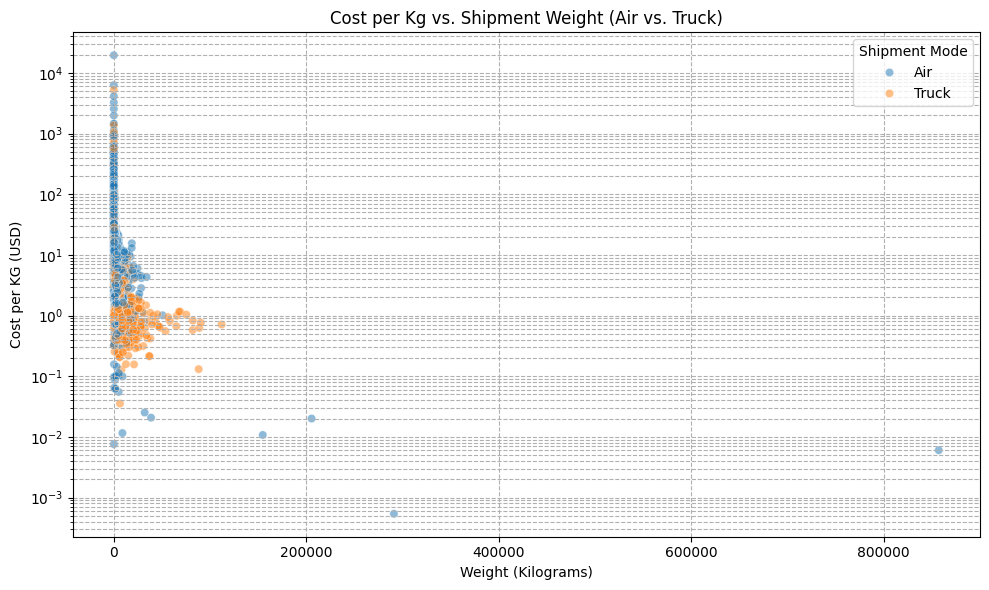

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

clean_df  = df.dropna(subset=['cost_per_kg', 'Shipment Mode'])
hypoth_df = clean_df[clean_df['Shipment Mode'].isin(['Air', 'Truck'])]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=hypoth_df, x='weight_kg', y='cost_per_kg', hue='Shipment Mode', alpha=0.5)
plt.title('Cost per Kg vs. Shipment Weight (Air vs. Truck)')
plt.xlabel('Weight (Kilograms)')
plt.ylabel('Cost per KG (USD)')
plt.yscale('log')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

**Interpretation of the Scatter Plot:**

1.  **Clear Separation by Shipment Mode:** The most striking observation is the distinct separation between 'Air' and 'Truck' shipments. 'Air' shipments (by blue points) consistently show a significantly higher `cost_per_kg` across all weight ranges compared to 'Truck' shipments (by orange points).

2.  **Logarithmic Scale:** The y-axis (`Cost per KG (USD)`) is on a logarithmic scale. The visual shows differences in cost are exponentially larger than they appear linearly.

3.  **Cost Behavior for Air Freight:** Air shipments, while potentially faster, are considerably more expensive per kilogram. Even for lighter loads, their `cost_per_kg` is high, and while it might slightly decrease or remain high as weight increases, it rarely approaches the cost efficiency of trucking.

4.  **Cost Behavior for Truck Freight:** Truck shipments demonstrate much lower `cost_per_kg` values. As weight increases, truck transport appears to benefit from better economies of scale, maintaining a relatively lower `cost_per_kg` compared to air freight.

5.  **Hypothesis Confirmation:** This visualization strongly supports the initial hypothesis: **Truck shipments are significantly more cost-effective on a per-kilogram basis than air shipments, especially as the weight of the shipment increases.** For heavy loads, the cost premium for air freight is substantial.

In essence, if cost is a primary concern for heavy shipments, trucking is the overwhelmingly more economical choice based on the data.

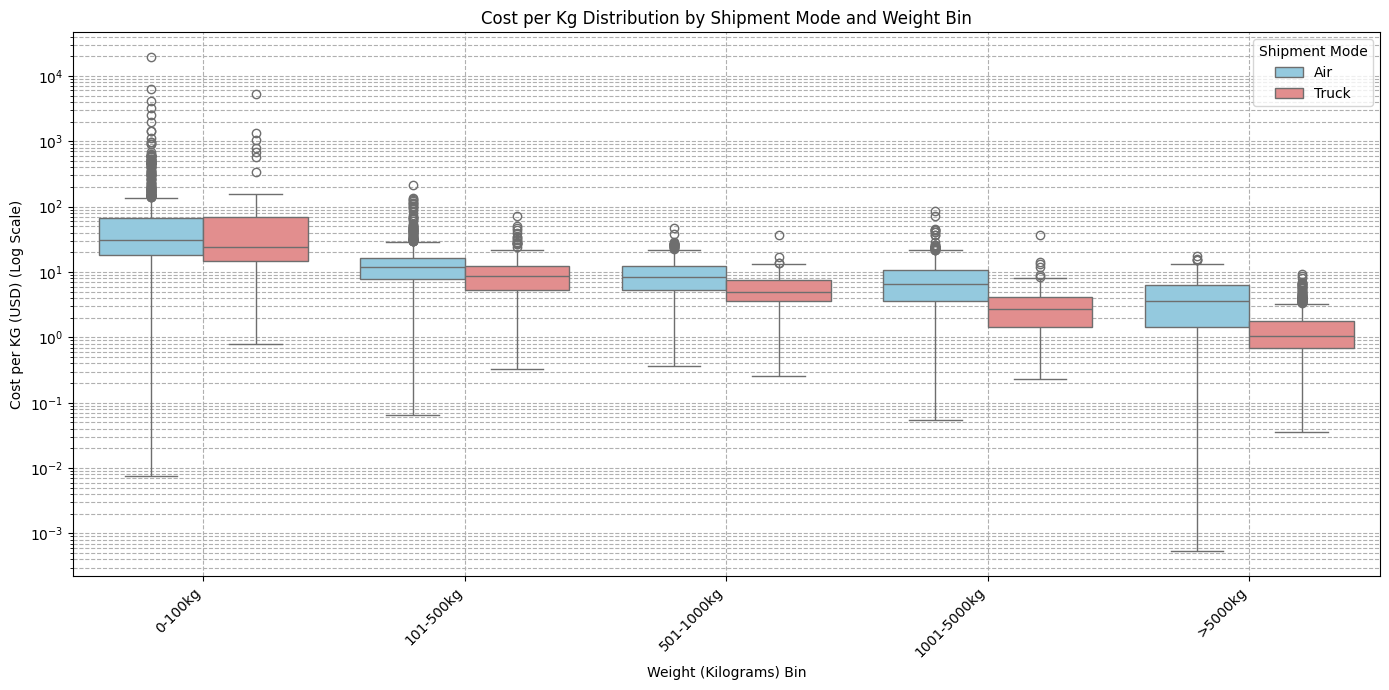

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare the DataFrame as before
clean_df  = df.dropna(subset=['cost_per_kg', 'Shipment Mode'])
hypoth_df = clean_df[clean_df['Shipment Mode'].isin(['Air', 'Truck'])]

# Create weight bins for box plots
hypoth_df['weight_bin'] = pd.cut(hypoth_df['weight_kg'],
                                 bins=[0, 100, 500, 1000, 5000, hypoth_df['weight_kg'].max()],
                                 labels=['0-100kg', '101-500kg', '501-1000kg', '1001-5000kg', '>5000kg'],
                                 right=True)

# Box Plot of Cost per Kg by Shipment Mode and Weight Bin
plt.figure(figsize=(14, 7))
sns.boxplot(data=hypoth_df, x='weight_bin', y='cost_per_kg', hue='Shipment Mode', palette={'Air': 'skyblue', 'Truck': 'lightcoral'})
plt.title('Cost per Kg Distribution by Shipment Mode and Weight Bin')
plt.xlabel('Weight (Kilograms) Bin')
plt.ylabel('Cost per KG (USD) (Log Scale)')
plt.yscale('log') # Use log scale for y-axis due to wide range
plt.grid(True, which='both', ls='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Interpretation of the Box Plot cost per Kg Distribution by shipment:**

1.  **Clear Cost Disparity Across Modes:** For every single weight bin (`0-100kg`, `101-500kg`, etc.), the 'Air' shipment mode (represented by the skyblue boxes) consistently shows a significantly higher median `cost_per_kg` compared to the 'Truck' shipment mode (represented by the lightcoral boxes).

2.  **Impact of Weight on Cost:** As you move from lower weight bins to higher weight bins, the overall `cost_per_kg` for both modes tends to decrease or stabilize, but the absolute difference between 'Air' and 'Truck' remains substantial. The plot uses a logarithmic y-axis (`Cost per KG (USD)`), which compresses very large values, yet the separation is still extremely clear.

3.  **Economies of Scale for Trucking:** The box plots for 'Truck' shipments generally show lower and often tighter distributions of `cost_per_kg` for heavier loads. This suggests that trucking benefits more from economies of scale as weight increases, maintaining a relatively consistent and low per-kilogram cost.

4.  **Air Freight Premium:** Air freight maintains a very high premium across all weight categories. Even the lowest `cost_per_kg` values for air shipments often exceed the highest `cost_per_kg` values for truck shipments within comparable weight bins.

5.  **Outliers:** Outliers are shown above or below the whiskers for some boxes. These indicate shipments with unusually high or low `cost_per_kg` within their respective weight bin and shipment mode.

**Conclusion:** This box plot strongly reinforces the hypothesis that **truck shipments are vastly more cost-effective on a per-kilogram basis than air shipments, particularly for heavier loads.** Organizations prioritizing cost efficiency for bulkier goods should strongly favor truck transport where feasible, as the financial savings compared to air freight are substantial across all weight ranges shown.

In [ ]:
# Delivery performance breakdown by shipment mode
performance_summary = df.groupby('Shipment Mode')['delivery_status'].value_counts(normalize=True).unstack(fill_value=0)
print('Delivery Performance by Shipment Mode (%):')
(performance_summary * 100).round(2)

Delivery Performance by Shipment Mode (%):


delivery_status,Late,On-Time,Suspect
Shipment Mode,,,
Air,9.60,83.71,6.69
Air Charter,11.54,68.46,20.00
N/A,1.11,97.78,1.11
Ocean,17.52,80.86,1.62
Truck,16.08,71.41,12.51


The table showing 'Delivery Performance by Shipment Mode (%)' provides a breakdown of how frequently each shipment mode falls into 'Late', 'On-Time', or 'Suspect' delivery statuses. Let's interpret these results:

**Air**:
On-Time (83.71%): A vast majority of air shipments are delivered on time, indicating good reliability in terms of meeting schedules.
Late (9.60%): A relatively small percentage of air shipments experience delays.
Suspect (6.69%): There's a notable portion of 'Suspect' entries, which might suggest data entry errors or unusual delivery dates in the records for air shipments.

**Air Charter**:
On-Time (68.46%): While still the majority, 'Air Charter' has a lower 'On-Time' rate compared to regular 'Air' shipments.
Late (11.54%): A higher percentage of charter flights are late.
Suspect (20.00%): This category has the highest percentage of 'Suspect' entries, which could point to more complex scheduling, bespoke routes, or greater data challenges for charter operations.

**N/A:**
On-Time (97.78%): Shipments categorized as 'N/A' (possibly indicating local or internal fulfillment without a specified mode) show an extremely high 'On-Time' rate, suggesting they are very reliable or have less rigorous tracking.
Late (1.11%) & Suspect (1.11%): Very low percentages for these categories.

**Ocean:**
On-Time (80.86%): Ocean freight, despite its slower nature, shows a good 'On-Time' performance, indicating adherence to its typically longer schedules.
Late (17.52%): Has the highest 'Late' percentage among all modes, which is somewhat expected given the complexities and variables involved in sea transport (e.g., port congestion, weather).
Suspect (1.62%): A very low 'Suspect' rate, suggesting better data quality or simpler recording for delivery dates.

**Truck:**
On-Time (71.41%): 'Truck' shipments have a lower 'On-Time' rate compared to 'Air' and 'Ocean'.
Late (16.08%): A significant portion of truck shipments are late, second only to 'Ocean'. This could be due to ground infrastructure challenges, traffic, or road conditions, aligning with our earlier hypothesis.
Suspect (12.51%): 'Truck' also shows a high 'Suspect' rate, indicating potential data entry issues or complexities in recording deliveries for ground transport.

**Key Takeaways:**

Air freight is generally the most reliable for on-time delivery, though 'N/A' category performs exceptionally well.
Ocean freight has the highest lateness, as might be expected given its operational characteristics.
Truck and Air Charter have higher 'Suspect' rates, which warrants further investigation into data quality or the unique operational aspects of these modes.
These insights can help in making decisions regarding the trade-off between cost-effectiveness (as seen in the previous plots) and delivery timeliness for different shipment modes.

In [ ]:
# SQL summary: median and average cost/kg for Air vs. Truck
con = duckdb.connect('scms_raw.duckdb')
result = con.execute('''
    SELECT
        "Shipment Mode",
        COUNT(*)                          AS shipments,
        ROUND(MEDIAN(weight_kg),   1)     AS median_weight_kg,
        ROUND(MEDIAN(cost_per_kg), 2)     AS median_cost_per_kg,
        ROUND(AVG(cost_per_kg),    2)     AS avg_cost_per_kg
    FROM clean_shipments
    WHERE cost_per_kg IS NOT NULL
      AND "Shipment Mode" IN (\'Air\', \'Truck\')
    GROUP BY 1
    ORDER BY median_cost_per_kg DESC
''').df()
print(result)
con.close()

  Shipment Mode  shipments  median_weight_kg  median_cost_per_kg  \
0           Air       4096             656.0               10.02   
1         Truck       1162            2673.0                2.50   

   avg_cost_per_kg  
0            33.52  
1            14.44  


**Shipment Mode Comparison (Air vs. Truck):**

*   **Air Shipments:**
    *   **Shipments (4096):** There are 4,096 air shipments included in this analysis.
    *   **Median Weight (656.0 kg):** The typical (median) weight for air shipments is relatively lower.
    *   **Median Cost per Kg (10.02):** Air freight has a significantly higher median cost per kilogram.
    *   **Average Cost per Kg (33.52):** The average cost per kilogram for air shipments is even higher than the median, suggesting some very expensive outliers or a skewed distribution towards higher costs.

*   **Truck Shipments:**
    *   **Shipments (1162):** There are 1,162 truck shipments in the analysis.
    *   **Median Weight (2673.0 kg):** Truck shipments, on average, handle much heavier loads compared to air shipments.
    *   **Median Cost per Kg (2.50):** Trucking is considerably more cost-effective per kilogram, with a median cost that is approximately four times lower than air freight.
    *   **Average Cost per Kg (14.44):** The average cost per kilogram for truck shipments is also higher than its median, but still substantially lower than the average for air freight.


**Key Findings:**

1.  **Cost-Effectiveness:** Trucking is clearly more cost-effective on a per-kilogram basis than air freight, with both median and average costs being significantly lower for truck shipments.
2.  **Weight Capacity:** Truck shipments tend to handle much larger volumes and weights, indicating their suitability for bulk cargo.
3.  **Cost Spreading:** The difference between median and average `cost_per_kg` for both modes suggests variability in pricing, potentially due to factors like distance, urgency, or specific routes. The larger gap for air freight might indicate a wider range of high-cost scenarios.

This summary reinforces the conclusions from the visualizations: for heavy loads and cost-efficiency, truck transport is the preferred option.

### Export: Dashboard-Ready CSV

In [ ]:
import duckdb, pandas as pd

con = duckdb.connect('scms_raw.duckdb')
df  = con.execute('SELECT * FROM clean_shipments').df()
df.to_csv('scms_clean.csv', index=False)
print(f'Exported {len(df)} rows to scms_clean2.csv')
con.close()

Exported 10324 rows to scms_clean2.csv


Exported the `scms_clean.csv` for connection to Apache Superset / Preset.io.